In [1]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import xarray as xr
from MHW_funcs import get_oisst_flag, get_oisst_flag_spatialONLY
from MHW_funcs import map_study_region
import matplotlib.pyplot as plt
import matplotlib.colors as mpcolors
from cmocean import cm as cmo
from cartopy import crs as ccrs
from cartopy import feature as cfeature 
import matplotlib.ticker as ticker
import boto3
import gsw
import datetime
import s3fs
import cmocean
import subprocess

BOLD = "\033[1m"
RESET = "\033[0m"
RED = "\033[31m"
LINE = "\033[4m"

In [2]:
def get_crocolake_data_MHW(MHW = "SWP2023", z = 500,
                           oxygen = False, pH = False,
                           BBP = False, CHLA = False,
                           CP = False, CDOM = False, turbidity = False, 
                           DownwellingIR = False, UpwellingIR = False, DownwellingPAR = False,
                           nitrate = False, silicate = False, phosphate = False,
                           alkalinity = False, DIC = False, 
                           bad_vals = [0,3,4,6,7,9]):
    # --------------
    # Identify MHW
    # --------------
    # Southwest Pacific 2023
    if "SWP" in MHW or ("Pac" in MHW and "2023" in MHW):
        print("Southwest Pacific 2023 chosen.")
        lat0 = -60
        lat1 = -40 
        lon0 = 150 
        lon1 = -140
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2022-11-17")
        date1 = pd.to_datetime("2024-01-01")
    # North Atlantic 2023
    elif ("NA" in MHW or "Atl" in MHW) and "2023" in MHW:
        print("North Atlantic 2023 chosen.")
        lat0 = 10
        lat1 = 60 
        lon0 = -60 
        lon1 = -10
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2022-10-01")
        date1 = pd.to_datetime("2024-06-01")
    # Northwest Pacific 2025
    elif("NWP" in MHW or "Pac" in MHW) and "2025" in MHW:
        print("Northwest Pacific 2025 chosen.")
        lat0 = 15
        lat1 = 55 
        lon0 = 130 
        lon1 = 180
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2025-05-01")
        date1 = pd.to_datetime("2026-08-01")
    # Northeast Pacific 2026
    elif("NEP" in MHW or "Pac" in MHW) and "2026" in MHW:
        print("Northeast Pacific 2026 chosen.")
        lat0 = 10
        lat1 = 35 
        lon0 = -150 
        lon1 = -100
        z0 = 0
        z1 = z
        date0 = pd.to_datetime("2025-09-01")
        date1 = pd.to_datetime("2026-07-01")
    else:
        print("Choose from the following: Southwest Pacific 2023, North Atlantic 2023, Northwest Pacific 2025, or Northeast Pacific 2026")
        return

    # Output bounds of MHW
    temp = {"Name": [MHW], 
            "lat0": [lat0], 
            "lat1": [lat1], 
            "lon0": [lon0], 
            "lon1": [lon1],
            "z0": [z0], 
            "z1": [z1], 
            "date0": [date0], 
            "date1": [date1]}
    mhw_info = pd.DataFrame(temp)
    del temp

    # --------------
    # Get Crocolake data
    # https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    # --------------
    
    # Directories (may need to be updated)
    parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'
    BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

    # If lon crosses 180deg
    if lon0 > lon1:
        # First half of meridional domain
        filters1 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                    ("JULD",">",date0), ("JULD","<",date1),
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
        df1 = df1.read().to_pandas()
    
        # Second half of meridional domain
        filters2 = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                    ("JULD",">",date0), ("JULD","<",date1),
                    ("PRES","<",z1), #("PRES",">=",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
        df2 = df2.read().to_pandas()
    
        # Combine domains
        df = pd.concat([df1, df2], ignore_index=True)
    
    # If lon does NOT cross 180deg (normal case)
    else:
        filters = [
                    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                    ("JULD",">",date0), ("JULD","<",date1),
                    ("PRES","<",z1), #("PRES",">",z0),
                    # ("DB_NAME","=","ARGO") 
                    ]
        df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
        df = df.read().to_pandas()

    # --------------
    # Select Crocolake data
    # https://crocolakedocs.readthedocs.io/en/latest/crocolake.html
    # --------------
    
    base_info = ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 
                 'PRES', 'TEMP', 'PSAL']
    oxygen_info = [item for item in list(df.keys()) if "DOXY" in item and "DATA_MODE" not in item]
    bbp_info = [item for item in list(df.keys()) if "BBP" in item and "DATA_MODE" not in item]
    chla_info = [item for item in list(df.keys()) if "CHL" in item and "DATA_MODE" not in item]
    downirrad_info = [item for item in list(df.keys()) if "DOWN_" in item and "DATA_MODE" not in item]
    ph_info = [item for item in list(df.keys()) if "PH" in item and "DATA_MODE" not in item]
    nitrate_info = [item for item in list(df.keys()) if "NITR" in item and "DATA_MODE" not in item]
    cp_info = [item for item in list(df.keys()) if "CP" in item and "DATA_MODE" not in item]
    turbidity_info = [item for item in list(df.keys()) if "TURB" in item and "DATA_MODE" not in item]
    upirrad_info = [item for item in list(df.keys()) if "UP_" in item and "DATA_MODE" not in item]
    downpar_info = [item for item in list(df.keys()) if "PAR" in item and "DATA_MODE" not in item]
    tco2_info = [item for item in list(df.keys()) if "TCO2" in item and "DATA_MODE" not in item]
    alk_info = [item for item in list(df.keys()) if "ALK" in item and "DATA_MODE" not in item]
    silicate_info = [item for item in list(df.keys()) if "SIL" in item and "DATA_MODE" not in item]
    phosphate_info = [item for item in list(df.keys()) if "PHOS" in item and "DATA_MODE" not in item]
    cdom_info = [item for item in list(df.keys()) if "CDOM" in item and "DATA_MODE" not in item]

    params = base_info

    if oxygen:
        params = params + oxygen_info
    if BBP:
        params = params + bbp_info
    if turbidity:
        params = params + turbidity_info
    if CHLA:
        params = params + chla_info
    if CP:
        params = params + cp_info
    if CDOM:
        params = params + cdom_info
    if nitrate:
        params = params + nitrate_info
    if silicate:
        params = params + silicate_info
    if phosphate:
        params = params + phosphate_info
    if pH:
        params = params + ph_info
    if alkalinity:
        params = params + alk_info
    if DIC:
        params = params + tco2_info
    if DownwellingIR:
        params = params + downirrad_info
    if UpwellingIR:
        params = params + upirrad_info
    if DownwellingPAR:
        params = params + downpar_info

    df = df.loc[:,params]

    # --------------
    # Filter out bad data
    # --------------

    qc_strings = [s for s in params if s.endswith("QC")]

    for s in qc_strings:
        var = s.removesuffix("_QC")
        df.loc[df[s].isin(bad_vals), var] = np.nan

    for col in params:
        if col != 'JULD':
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')
    df = df.drop(columns=[col for col in df.columns if col.endswith('_QC')])
    print(f"You have selected the following parameters after QC: {list(df.keys())}")

    # --------------
    # Add more variables: week number, depth, absolute salinity, conservative temperature, density
    # --------------
    df['Week'] = df['JULD'].dt.isocalendar().week
    df['Depth'] = gsw.z_from_p(df['PRES'], df['LATITUDE'])
    df['ASAL'] = gsw.SA_from_SP(df['PSAL'], df['PRES'], df['LONGITUDE'], df['LATITUDE'])
    df['CTEMP'] = gsw.CT_from_t(df['ASAL'], df['TEMP'], df['PRES'])
    df['sigma0'] = gsw.sigma0(df['ASAL'], df['CTEMP'])

    return df, mhw_info
        

In [41]:
df, mhw_info = get_crocolake_data_MHW(MHW = "SWP2023", z = 500, CHLA = True, BBP = True, 
                                      nitrate = True, oxygen = True, pH = True)

Southwest Pacific 2023 chosen.


You have selected the following parameters after QC: ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 'PRES', 'TEMP', 'PSAL', 'DOXY', 'DOXY_ERROR', 'BBP', 'BBP_ERROR', 'BBP470', 'BBP470_ERROR', 'BBP532', 'BBP532_ERROR', 'BBP700', 'BBP700_ERROR', 'CHLA', 'CHLA_ERROR', 'NITRATE', 'NITRATE_ERROR', 'PH_IN_SITU_TOTAL', 'PH_IN_SITU_TOTAL_ERROR', 'PHOSPHATE', 'PHOSPHATE_ERROR']


In [4]:
def despike(df, 
            BBP_SMOOTH_MODE = "cornec",
            CHL_MEDIAN_WINDOW = 7,
            BBP_MEDIAN_WINDOW = 5,
            BBP_MEAN_WINDOW = 5,
            DCM_MEDIAN_WINDOW = 5):

    """Vertical despiking on the native profile resolution.

    Based on function written by Clara Vives: 
        - https://github.com/go-bgc/Marine-Heat-Waves/tree/main/contributors/Clara

    chl gets a 7-point running median (Su et al. 2021, as used by Vives et al.
    2025 Sect. 2.1.1). bbp gets the Cornec, Claustre et al. (2021) filter — a
    5-point running median followed by a 5-point running mean — because bbp
    carries sharp particle-aggregate spikes that a median alone leaves a step
    at. Both are centred with min_periods=1, so the top and bottom of a profile
    survive instead of turning into NaN.

    Profiles are sorted by PRES first: a running filter over unsorted levels is
    meaningless, and Sprof level order is not guaranteed.
    """
    df = df.sort_values(["PLATFORM_NUMBER", "CYCLE_NUMBER", "PRES"]).copy()
    grouped = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)

    if "CHLA" in df.keys():
        
        df["CHLA_RAW"] = df["CHLA"]
        df["CHLA"] = grouped["CHLA"].transform(
        lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())

    if "BBP700" in df.keys():
        df["BBP700_RAW"] = df["BBP700"]
    
        if BBP_SMOOTH_MODE == "cornec":
            med = grouped["BBP700"].transform(
                lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
            df["BBP700"] = med
            df["BBP700"] = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)["BBP700"].transform(
                lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())
        else:
            df["BBP700"] = grouped["BBP700"].transform(
                lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())

    if "BBP470" in df.keys():
        df["BBP470_RAW"] = df["BBP470"]
    
        if BBP_SMOOTH_MODE == "cornec":
            med = grouped["BBP470"].transform(
                lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
            df["BBP470"] = med
            df["BBP470"] = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)["BBP470"].transform(
                lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())
        else:
            df["BBP470"] = grouped["BBP470"].transform(
                lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())

    if "BBP532" in df.keys():
        df["BBP532_RAW"] = df["BBP532"]
    
        if BBP_SMOOTH_MODE == "cornec":
            med = grouped["BBP532"].transform(
                lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
            df["BBP532"] = med
            df["BBP532"] = df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], sort=False)["BBP532"].transform(
                lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())
        else:
            df["BBP532"] = grouped["BBP532"].transform(
                lambda s: s.rolling(CHL_MEDIAN_WINDOW, center=True, min_periods=1).median())
    return df

In [42]:
df2 = despike(df)
df2.keys()

Index(['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD',
       'PRES', 'TEMP', 'PSAL', 'DOXY', 'DOXY_ERROR', 'BBP', 'BBP_ERROR',
       'BBP470', 'BBP470_ERROR', 'BBP532', 'BBP532_ERROR', 'BBP700',
       'BBP700_ERROR', 'CHLA', 'CHLA_ERROR', 'NITRATE', 'NITRATE_ERROR',
       'PH_IN_SITU_TOTAL', 'PH_IN_SITU_TOTAL_ERROR', 'PHOSPHATE',
       'PHOSPHATE_ERROR', 'Week', 'Depth', 'ASAL', 'CTEMP', 'sigma0',
       'CHLA_RAW', 'BBP700_RAW', 'BBP470_RAW', 'BBP532_RAW'],
      dtype='str')

In [6]:
def profile_coverage_qc(df, FIRST_PRES_MAX = 10.0, MIN_OBS_300 = 20, INTERP_MAX = 500.0):
    """Drop whole profiles that are too sparse to integrate (Vives et al. 2025).

    (a) the shallowest pressure must be in the upper FIRST_PRES_MAX m, and
    (b) the upper 300 m must carry at least MIN_OBS_300 observations of BOTH
        chl and bbp.
    Returns (kept, report) so the caller can print how many went and why.

    Based on function written by Clara Vives: 
        - https://github.com/go-bgc/Marine-Heat-Waves/tree/main/contributors/Clara
    """

    keys = ["PLATFORM_NUMBER", "CYCLE_NUMBER"]
    upper = df[df["PRES"] <= INTERP_MAX]
    stats = upper.groupby(keys).agg(
        first_pres=("PRES", "min"),
        n_chl=("CHLA", "count"),
        n_bbp=("BBP700", "count"))

    shallow_ok = stats["first_pres"] <= FIRST_PRES_MAX
    count_ok = (stats["n_chl"] >= MIN_OBS_300) & (stats["n_bbp"] >= MIN_OBS_300)
    good = stats.index[shallow_ok & count_ok]

    report = dict(n_profiles=len(stats),
                  fail_first_pres=int((~shallow_ok).sum()),
                  fail_n_obs=int((~count_ok).sum()),
                  kept=len(good))
    kept = df.set_index(keys).loc[good].reset_index()
    return kept, report

In [8]:
def profile_coverage_qc(
    df,
    variables,
    FIRST_PRES_MAX=10.0,
    COUNT_PRES_MAX=300.0,
    MIN_OBS=20
):
    """
    Drop whole profiles that are too sparse for analysis.

    A profile is retained if:
      (a) the shallowest pressure is <= FIRST_PRES_MAX, and
      (b) each variable in `variables` has at least MIN_OBS valid
          observations within the upper COUNT_PRES_MAX dbar.

    Returns
    -------
    kept : pandas.DataFrame
        Profiles passing QC.

    report : dict
        Summary of QC failures.
    """

    keys = ["PLATFORM_NUMBER", "CYCLE_NUMBER"]

    # Only use the upper portion of each profile for the observation-count QC
    upper = df[df["PRES"] <= COUNT_PRES_MAX]

    # Build aggregation dynamically
    agg_dict = {
        "first_pres": ("PRES", "min")
    }

    for var in variables:
        agg_dict[f"n_{var}"] = (var, "count")

    stats = upper.groupby(keys).agg(**agg_dict)

    # -------------------------
    # QC conditions
    # -------------------------

    shallow_ok = stats["first_pres"] <= FIRST_PRES_MAX

    count_cols = [f"n_{var}" for var in variables]

    count_ok = (
        stats[count_cols] >= MIN_OBS
    ).all(axis=1)

    good = stats.index[shallow_ok & count_ok]

    # -------------------------
    # QC report
    # -------------------------

    report = {
        "n_profiles": len(stats),
        "fail_first_pres": int((~shallow_ok).sum()),
        "fail_n_obs_any_variable": int((~count_ok).sum()),
        "kept": len(good)
    }

    # Report failures by variable
    for var in variables:
        report[f"fail_{var}"] = int(
            (stats[f"n_{var}"] < MIN_OBS).sum()
        )

    # Keep entire profile, not just upper 300 m
    kept = (
        df.set_index(keys)
        .loc[good]
        .reset_index()
    )

    return kept, report

In [43]:
df3, report = profile_coverage_qc(
    df2,
    variables=[
        "CHLA",
        "BBP700",
        "NITRATE",
        "DOXY",
        "PH_IN_SITU_TOTAL",
    ]
)

print(report)

{'n_profiles': 593, 'fail_first_pres': 0, 'fail_n_obs_any_variable': 268, 'kept': 325, 'fail_CHLA': 13, 'fail_BBP700': 28, 'fail_NITRATE': 97, 'fail_DOXY': 28, 'fail_PH_IN_SITU_TOTAL': 211}


In [30]:
def regrid_1m(df, INTERP_DZ = 1.0, INTERP_MAX = 500.0, 
              DCM_MEDIAN_WINDOW = 5,
              BBP_MEDIAN_WINDOW = 5,
              BBP_MEAN_WINDOW = 5):
    """Extrapolate each profile to the surface, then interpolate chl and bbp to
    a 1 m grid from 0 to 300 m (Vives et al. 2025, Sect. 2.1).

    The surface extrapolation is constant, not linear: the shallowest good
    value is carried up to 0 m. Extrapolating a gradient through the top few
    metres of a fluorescence profile invents a quenching signal that is not in
    the data.

    Two extra fields are built ON this grid, kept separate from the analysis
    fields exactly as the paper separates them, for later DCM/DBM work:
      CHLA_DCM   5-point running median
      BBP700_DBM 5-point running median then 5-point running mean

    Based on function written by Clara Vives: 
        - https://github.com/go-bgc/Marine-Heat-Waves/tree/main/contributors/Clara
    """

    # 1 m regrid, Vives et al. (2025) Sect. 2.1
    INTERP_GRID = np.arange(0.0, INTERP_MAX + INTERP_DZ, INTERP_DZ)
    
    keys = ["PLATFORM_NUMBER", "CYCLE_NUMBER"]
    meta_cols = ["JULD", "LATITUDE", "LONGITUDE"]
    out = []
    for (wmo, cycle), prof in df.groupby(keys, sort=False):
        prof = prof.sort_values("PRES")
        rec = {"PLATFORM_NUMBER": wmo, "CYCLE_NUMBER": cycle, "PRES": INTERP_GRID}

        # Don't interpolate these columns
        no_interp = ['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD',
                     'PRES', 'Week', 'Depth', 'sigma0']
        # List out all the columns that can be interpolate
        COLS = [item for item in list(df.keys()) if item not in no_interp and "_ERROR" not in item]

        # Do the interpolating
        for col in COLS:
            good = prof.dropna(subset=[col])
            if len(good) < 2:
                rec[col] = np.full(INTERP_GRID.shape, np.nan)
                continue
            z, v = good["PRES"].values, good[col].values
            # np.interp holds the end values flat outside the data range, which
            # is exactly the constant surface extrapolation we want
            interp = np.interp(INTERP_GRID, z, v)
            interp[INTERP_GRID > z[-1]] = np.nan      # never extrapolate downward
            rec[col] = interp
        block = pd.DataFrame(rec)
        for col in meta_cols:
            block[col] = prof[col].iloc[0]
        out.append(block)

    grid = pd.concat(out, ignore_index=True)
    grouped = grid.groupby(keys, sort=False)
    grid["CHLA_DCM"] = grouped["CHLA"].transform(
        lambda s: s.rolling(DCM_MEDIAN_WINDOW, center=True, min_periods=1).median())
    bbp_med = grouped["BBP700"].transform(
        lambda s: s.rolling(BBP_MEDIAN_WINDOW, center=True, min_periods=1).median())
    grid["BBP700_DBM"] = bbp_med
    grid["BBP700_DBM"] = grid.groupby(keys, sort=False)["BBP700_DBM"].transform(
        lambda s: s.rolling(BBP_MEAN_WINDOW, center=True, min_periods=1).mean())

    # Add back in variables that could not be interpolated
    grid['Week'] = grid['JULD'].dt.isocalendar().week
    grid['Depth'] = gsw.z_from_p(grid['PRES'], grid['LATITUDE'])
    grid['sigma0'] = gsw.sigma0(grid['ASAL'], grid['CTEMP'])
    return grid

In [44]:
df4 = regrid_1m(df3)
df4

,PLATFORM_NUMBER,CYCLE_NUMBER,PRES,TEMP,PSAL,DOXY,BBP,BBP470,BBP532,BBP700,...,BBP470_RAW,BBP532_RAW,JULD,LATITUDE,LONGITUDE,CHLA_DCM,BBP700_DBM,Week,Depth,sigma0
0,2903456.0,1.0,0.0,6.085000,33.945904,300.019684,NaN,NaN,NaN,0.000494,...,NaN,NaN,2023-06-09 13:55:04.001474560,-55.053000,-159.929000,0.087769,0.000494,23,-0.000000,26.710549
1,2903456.0,1.0,1.0,6.085000,33.945904,300.019684,NaN,NaN,NaN,0.000494,...,NaN,NaN,2023-06-09 13:55:04.001474560,-55.053000,-159.929000,0.087769,0.000494,23,-0.990980,26.710549
2,2903456.0,1.0,2.0,6.085000,33.945904,300.019684,NaN,NaN,NaN,0.000494,...,NaN,NaN,2023-06-09 13:55:04.001474560,-55.053000,-159.929000,0.087769,0.000494,23,-1.981956,26.710549
3,2903456.0,1.0,3.0,6.085300,33.945904,300.019684,NaN,NaN,NaN,0.000494,...,NaN,NaN,2023-06-09 13:55:04.001474560,-55.053000,-159.929000,0.087769,0.000494,23,-2.972926,26.710515
4,2903456.0,1.0,4.0,6.085888,33.945904,300.019684,NaN,NaN,NaN,0.000494,...,NaN,NaN,2023-06-09 13:55:04.001474560,-55.053000,-159.929000,0.087769,0.000494,23,-3.963892,26.710447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162820,5906624.0,160.0,496.0,3.525200,34.161658,242.354148,NaN,NaN,NaN,0.000405,...,NaN,NaN,2023-03-09 13:02:08.000000000,-58.436099,178.837727,0.000502,0.000401,10,-490.797823,27.172836
162821,5906624.0,160.0,497.0,3.529818,34.163244,241.799662,NaN,NaN,NaN,0.000407,...,NaN,NaN,2023-03-09 13:02:08.000000000,-58.436099,178.837727,0.000502,0.000406,10,-491.786151,27.173667
162822,5906624.0,160.0,498.0,3.538000,34.165546,241.288536,NaN,NaN,NaN,0.000410,...,NaN,NaN,2023-03-09 13:02:08.000000000,-58.436099,178.837727,0.000294,0.000409,10,-492.774475,27.174725
162823,5906624.0,160.0,499.0,3.548500,34.168829,240.878593,NaN,NaN,NaN,0.000416,...,NaN,NaN,2023-03-09 13:02:08.000000000,-58.436099,178.837727,0.000502,0.000410,10,-493.762793,27.176340


In [12]:
def average_across_profiles(df):

    df = df.groupby(by = ['JULD', 'PRES']).mean().reset_index()

    return df

In [71]:
df5 = average_across_profiles(df4)
df5


,JULD,PRES,PLATFORM_NUMBER,CYCLE_NUMBER,TEMP,PSAL,DOXY,BBP,BBP470,BBP532,...,BBP700_RAW,BBP470_RAW,BBP532_RAW,LATITUDE,LONGITUDE,CHLA_DCM,BBP700_DBM,Week,Depth,sigma0
0,2022-11-17 22:33:08.000000000,0.0,5906624.0,150.0,4.401000,34.029083,315.228149,NaN,NaN,NaN,...,0.001301,NaN,NaN,-57.961764,178.788691,0.137638,0.001282,46.0,0.000000,26.972647
1,2022-11-17 22:33:08.000000000,1.0,5906624.0,150.0,4.399428,34.029785,315.328156,NaN,NaN,NaN,...,0.001301,NaN,NaN,-57.961764,178.788691,0.137638,0.001277,46.0,-0.990735,26.973380
2,2022-11-17 22:33:08.000000000,2.0,5906624.0,150.0,4.391571,34.033295,315.323120,NaN,NaN,NaN,...,0.001237,NaN,NaN,-57.961764,178.788691,0.137638,0.001277,46.0,-1.981466,26.977016
3,2022-11-17 22:33:08.000000000,3.0,5906624.0,150.0,4.390000,34.033892,315.344914,NaN,NaN,NaN,...,0.001633,NaN,NaN,-57.961764,178.788691,0.137638,0.001274,46.0,-2.972192,26.977666
4,2022-11-17 22:33:08.000000000,4.0,5906624.0,150.0,4.389500,34.032997,315.426956,NaN,NaN,NaN,...,0.001212,NaN,NaN,-57.961764,178.788691,0.137638,0.001267,46.0,-3.962913,26.977018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162820,2023-12-29 21:25:44.002289152,496.0,5906546.0,39.0,6.497620,34.310142,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-491.045192,26.951662
162821,2023-12-29 21:25:44.002289152,497.0,5906546.0,39.0,6.493445,34.309872,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-492.034018,26.952010
162822,2023-12-29 21:25:44.002289152,498.0,5906546.0,39.0,6.489945,34.309872,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-493.022840,26.952483
162823,2023-12-29 21:25:44.002289152,499.0,5906546.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-494.011657,NaN


In [12]:
df4

,PLATFORM_NUMBER,CYCLE_NUMBER,PRES,TEMP,PSAL,BBP,BBP470,BBP532,BBP700,CHLA,...,BBP470_RAW,BBP532_RAW,JULD,LATITUDE,LONGITUDE,CHLA_DCM,BBP700_DBM,Week,Depth,sigma0
0,2903455.0,1.0,0.0,0.050000,34.041885,NaN,NaN,NaN,0.000504,0.055212,...,NaN,NaN,2023-06-11 06:21:07.000674304,-59.297100,-149.871500,0.055212,0.000504,23,-0.000000,27.334133
1,2903455.0,1.0,1.0,0.050000,34.041885,NaN,NaN,NaN,0.000504,0.055212,...,NaN,NaN,2023-06-11 06:21:07.000674304,-59.297100,-149.871500,0.055212,0.000504,23,-0.990627,27.334133
2,2903455.0,1.0,2.0,0.050000,34.041885,NaN,NaN,NaN,0.000504,0.055212,...,NaN,NaN,2023-06-11 06:21:07.000674304,-59.297100,-149.871500,0.055212,0.000504,23,-1.981249,27.334133
3,2903455.0,1.0,3.0,0.050085,34.041801,NaN,NaN,NaN,0.000504,0.055212,...,NaN,NaN,2023-06-11 06:21:07.000674304,-59.297100,-149.871500,0.055212,0.000503,23,-2.971866,27.334058
4,2903455.0,1.0,4.0,0.050854,34.041032,NaN,NaN,NaN,0.000504,0.055212,...,NaN,NaN,2023-06-11 06:21:07.000674304,-59.297100,-149.871500,0.055212,0.000503,23,-3.962478,27.333373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283060,5906635.0,112.0,496.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2023-12-25 19:54:00.000000000,-41.150045,168.546027,0.004722,0.000282,52,-491.559055,NaN
283061,5906635.0,112.0,497.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2023-12-25 19:54:00.000000000,-41.150045,168.546027,0.004722,0.000282,52,-492.548916,NaN
283062,5906635.0,112.0,498.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2023-12-25 19:54:00.000000000,-41.150045,168.546027,NaN,0.000282,52,-493.538772,NaN
283063,5906635.0,112.0,499.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2023-12-25 19:54:00.000000000,-41.150045,168.546027,NaN,0.000281,52,-494.528624,NaN


In [15]:
def get_density_threshold_depth(group, delta_sigma=0.03):
    
    # Sort shallowest -> deepest
    group = group.sort_values('Depth', ascending=False)
    
    # Remove missing values
    group = group.dropna(subset=['Depth', 'sigma0'])
    
    if group.empty:
        return np.nan

    # sigma0 at shallowest depth in THIS profile
    shallow_sigma = group['sigma0'].iloc[0]
    
    # Target density
    target_sigma = shallow_sigma + delta_sigma
    
    # Measurements meeting/exceeding target
    hits = group[group['sigma0'] >= target_sigma]
    
    if hits.empty:
        return np.nan
    
    # First depth where density crosses threshold
    return hits['Depth'].iloc[0]

In [63]:
def get_nitrate_threshold_depth(group, threshold=1.0):

    group = group.sort_values("PRES").copy()
    valid = group.dropna(subset=["PRES", "Depth", "NITRATE"])

    if valid.empty:
        return np.nan

    surface_nitrate = valid.iloc[0]["NITRATE"]

    exceeds = valid[
        valid["NITRATE"] >= surface_nitrate + threshold
    ]

    if exceeds.empty:
        return np.nan

    return exceeds.iloc[0]["Depth"]

In [64]:
density_threshold_depth = (
    df5
    .groupby(["JULD", "PLATFORM_NUMBER", "CYCLE_NUMBER"])
    .apply(get_density_threshold_depth)
    .reset_index(name='density_threshold_depth')
)

nitrate_threshold_depth = (
    df5
    .groupby(["JULD", "PLATFORM_NUMBER", "CYCLE_NUMBER"])
    .apply(get_nitrate_threshold_depth)
    .reset_index(name='nitrate_threshold_depth')
)

In [54]:
density_threshold_depth

,JULD,PLATFORM_NUMBER,CYCLE_NUMBER,density_threshold_depth
0,2022-11-17 22:33:08.000000000,5906624.0,150.0,-51.511862
1,2022-11-18 02:41:17.000273920,5906311.0,68.0,-5.951228
2,2022-11-21 07:33:00.000000000,5905501.0,91.0,-55.538578
3,2022-11-22 07:33:00.000000000,5905505.0,91.0,-31.748926
4,2022-11-22 10:35:06.001123840,5906567.0,1.0,-28.770554
...,...,...,...,...
320,2023-12-23 18:51:53.002004992,5906550.0,37.0,-28.772302
321,2023-12-27 19:15:18.002060288,5906567.0,40.0,-26.790349
322,2023-12-27 21:31:28.002297856,5906443.0,36.0,-45.591029
323,2023-12-29 19:03:35.002042880,2903457.0,21.0,-60.481947


In [65]:
nitrate_threshold_depth

,JULD,PLATFORM_NUMBER,CYCLE_NUMBER,nitrate_threshold_depth
0,2022-11-17 22:33:08.000000000,5906624.0,150.0,-164.396287
1,2022-11-18 02:41:17.000273920,5906311.0,68.0,-85.284377
2,2022-11-21 07:33:00.000000000,5905501.0,91.0,-62.479840
3,2022-11-22 07:33:00.000000000,5905505.0,91.0,-40.677422
4,2022-11-22 10:35:06.001123840,5906567.0,1.0,-54.561401
...,...,...,...,...
320,2023-12-23 18:51:53.002004992,5906550.0,37.0,-59.524424
321,2023-12-27 19:15:18.002060288,5906567.0,40.0,-67.465278
322,2023-12-27 21:31:28.002297856,5906443.0,36.0,-163.485882
323,2023-12-29 19:03:35.002042880,2903457.0,21.0,-64.447351


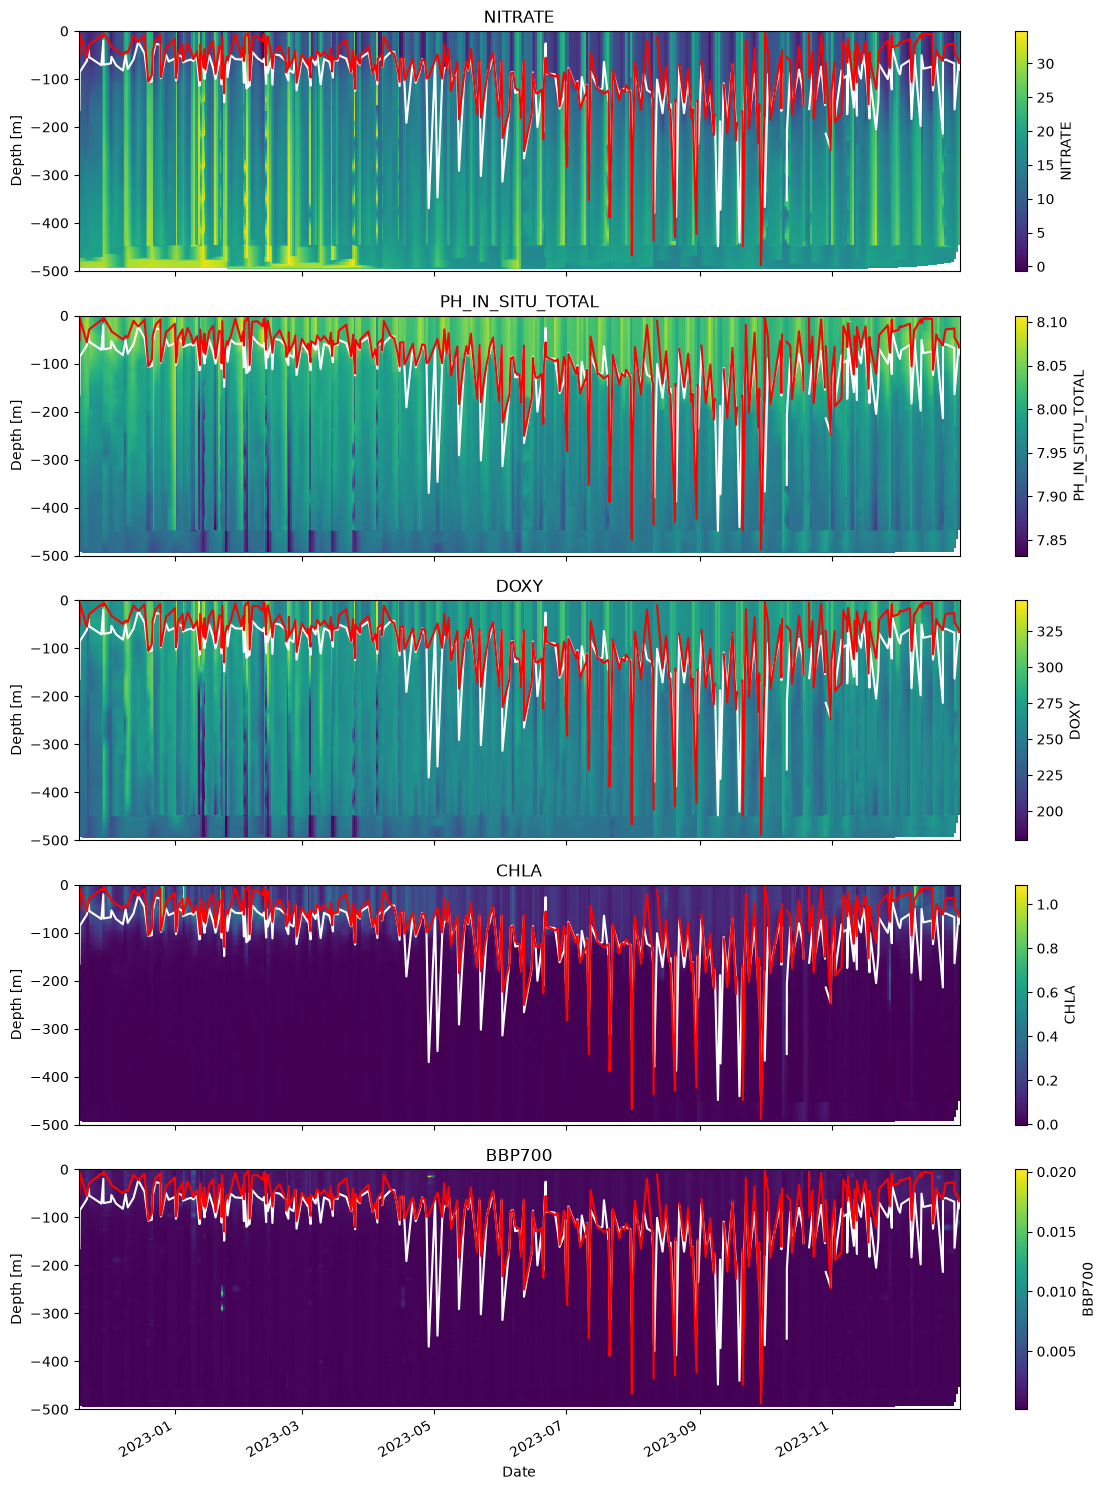

In [66]:
from scipy.interpolate import griddata
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

plottables = [
    "NITRATE",
    "PH_IN_SITU_TOTAL",
    "DOXY",
    "CHLA",
    "BBP700"
]

fig, axarr = plt.subplots(
    nrows=5,
    figsize=(12, 15),
    sharex=True
)

axarr = axarr.flatten()

for i, ax in enumerate(axarr):

    variable = plottables[i]

    # Only remove NaNs needed for THIS variable
    d = df5[["JULD", "Depth", variable]].dropna().copy()

    # Convert datetime to matplotlib numeric dates
    x = mdates.date2num(d["JULD"])
    y = d["Depth"].values
    z = d[variable].values

    # Regular interpolation grid
    xi = np.linspace(x.min(), x.max(), 500)
    yi = np.linspace(-500, 0, 250)

    XI, YI = np.meshgrid(xi, yi)

    # Interpolate
    ZI = griddata(
        (x, y),
        z,
        (XI, YI),
        method="linear"
    )

    # Plot
    im = ax.pcolormesh(
        XI,
        YI,
        ZI,
        shading="auto",
        cmap="viridis"
    )

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(variable)

    ax.set_ylabel("Depth [m]")
    ax.set_ylim(-500, 0)
    ax.set_title(variable)

    xx = nitrate_threshold_depth['JULD']
    yy = nitrate_threshold_depth['nitrate_threshold_depth']
    ax.plot(xx, yy, color = 'white')

    xx = density_threshold_depth['JULD']
    yy = density_threshold_depth['density_threshold_depth']
    ax.plot(xx, yy, color = 'red')

axarr[-1].set_xlabel("Date")

fig.autofmt_xdate()
plt.tight_layout()

In [67]:
def integrate_over_variable_depth(
    group,
    variable='CHLA_ADJUSTED',
    min_depth=0,
    max_depth=200
):
    """
    Integrate over the available portion of the requested depth interval.

    min_depth and max_depth can each be:
      - numeric constants, e.g. 0, 20, 200
      - column names, e.g. 'MLD'

    The requested interval is clipped to the range where valid data exist.

    Assumes:
      - dataframe Depth is negative downward
      - depth limits are interpreted as positive-down meters
    """

    # --------------------------------
    # Requested minimum depth
    # --------------------------------
    if isinstance(min_depth, str):
        requested_zmin = group[min_depth].iloc[0]
    else:
        requested_zmin = min_depth

    # --------------------------------
    # Requested maximum depth
    # --------------------------------
    if isinstance(max_depth, str):
        requested_zmax = group[max_depth].iloc[0]
    else:
        requested_zmax = max_depth

    if pd.isna(requested_zmin) or pd.isna(requested_zmax):
        return np.nan

    requested_zmin = abs(float(requested_zmin))
    requested_zmax = abs(float(requested_zmax))

    # Ensure shallow -> deep ordering
    if requested_zmin > requested_zmax:
        requested_zmin, requested_zmax = (
            requested_zmax,
            requested_zmin
        )

    # --------------------------------
    # Valid profile observations
    # --------------------------------
    g = group[['Depth', variable]].dropna().copy()

    if len(g) < 2:
        return np.nan

    # Convert negative-down to positive-down
    g['Depth_positive'] = -g['Depth']

    # Remove values above sea level
    g = g[g['Depth_positive'] >= 0]

    # Average duplicate depths and sort
    g = (
        g[['Depth_positive', variable]]
        .groupby('Depth_positive', as_index=False)
        .mean()
        .sort_values('Depth_positive')
    )

    if len(g) < 2:
        return np.nan

    # --------------------------------
    # Available depth range
    # --------------------------------
    shallowest_available = g['Depth_positive'].min()
    deepest_available = g['Depth_positive'].max()

    # Clip requested integration interval
    # to actual available data
    zmin = max(
        requested_zmin,
        shallowest_available
    )

    zmax = min(
        requested_zmax,
        deepest_available
    )

    # No overlap between requested interval and data
    if zmax <= zmin:
        return np.nan

    # --------------------------------
    # Interpolate at exact boundaries
    # --------------------------------
    value_min = np.interp(
        zmin,
        g['Depth_positive'].values,
        g[variable].values
    )

    value_max = np.interp(
        zmax,
        g['Depth_positive'].values,
        g[variable].values
    )

    # Observations inside interval
    g_int = g[
        (g['Depth_positive'] > zmin) &
        (g['Depth_positive'] < zmax)
    ].copy()

    # Add exact boundaries
    boundaries = pd.DataFrame({
        'Depth_positive': [zmin, zmax],
        variable: [value_min, value_max]
    })

    g_int = (
        pd.concat(
            [boundaries, g_int],
            ignore_index=True
        )
        .sort_values('Depth_positive')
    )

    if len(g_int) < 2:
        return np.nan

    return np.trapezoid(
        g_int[variable].values,
        x=g_int['Depth_positive'].values
    )

In [72]:
df5 = df5.merge(
    nitrate_threshold_depth,
    on=["JULD", "PLATFORM_NUMBER", "CYCLE_NUMBER"],
    how="left"
)

df5 = df5.merge(
    density_threshold_depth,
    on=["JULD", "PLATFORM_NUMBER", "CYCLE_NUMBER"],
    how="left"
)
df5

,JULD,PRES,PLATFORM_NUMBER,CYCLE_NUMBER,TEMP,PSAL,DOXY,BBP,BBP470,BBP532,...,BBP532_RAW,LATITUDE,LONGITUDE,CHLA_DCM,BBP700_DBM,Week,Depth,sigma0,nitrate_threshold_depth,density_threshold_depth
0,2022-11-17 22:33:08.000000000,0.0,5906624.0,150.0,4.401000,34.029083,315.228149,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001282,46.0,0.000000,26.972647,-164.396287,-51.511862
1,2022-11-17 22:33:08.000000000,1.0,5906624.0,150.0,4.399428,34.029785,315.328156,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001277,46.0,-0.990735,26.973380,-164.396287,-51.511862
2,2022-11-17 22:33:08.000000000,2.0,5906624.0,150.0,4.391571,34.033295,315.323120,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001277,46.0,-1.981466,26.977016,-164.396287,-51.511862
3,2022-11-17 22:33:08.000000000,3.0,5906624.0,150.0,4.390000,34.033892,315.344914,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001274,46.0,-2.972192,26.977666,-164.396287,-51.511862
4,2022-11-17 22:33:08.000000000,4.0,5906624.0,150.0,4.389500,34.032997,315.426956,NaN,NaN,NaN,...,NaN,-57.961764,178.788691,0.137638,0.001267,46.0,-3.962913,26.977018,-164.396287,-51.511862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162820,2023-12-29 21:25:44.002289152,496.0,5906546.0,39.0,6.497620,34.310142,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-491.045192,26.951662,-81.262084,-66.399484
162821,2023-12-29 21:25:44.002289152,497.0,5906546.0,39.0,6.493445,34.309872,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-492.034018,26.952010,-81.262084,-66.399484
162822,2023-12-29 21:25:44.002289152,498.0,5906546.0,39.0,6.489945,34.309872,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-493.022840,26.952483,-81.262084,-66.399484
162823,2023-12-29 21:25:44.002289152,499.0,5906546.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-52.580900,-151.169500,NaN,NaN,52.0,-494.011657,NaN,-81.262084,-66.399484


In [75]:
chla_integrated_nitracline = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA',
        min_depth=0,
        max_depth='nitrate_threshold_depth')
    .reset_index(name='CHLA_integrated')
)

chla_integrated_MLD = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA',
        min_depth=0,
        max_depth='density_threshold_depth')
    .reset_index(name='CHLA_integrated')
)

bbp_integrated_nitracline = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='BBP700',
        min_depth=0,
        max_depth='nitrate_threshold_depth')
    .reset_index(name='BBP700_integrated')
)

bbp_integrated_MLD = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='BBP700',
        min_depth=0,
        max_depth='density_threshold_depth')
    .reset_index(name='BBP700_integrated')
)

chla_integrated_200 = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA',
        min_depth=0,
        max_depth=200)
    .reset_index(name='CHLA_integrated')
)

bbp_integrated_200 = (
    df5
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='BBP700',
        min_depth=0,
        max_depth=200)
    .reset_index(name='BBP700_integrated')
)

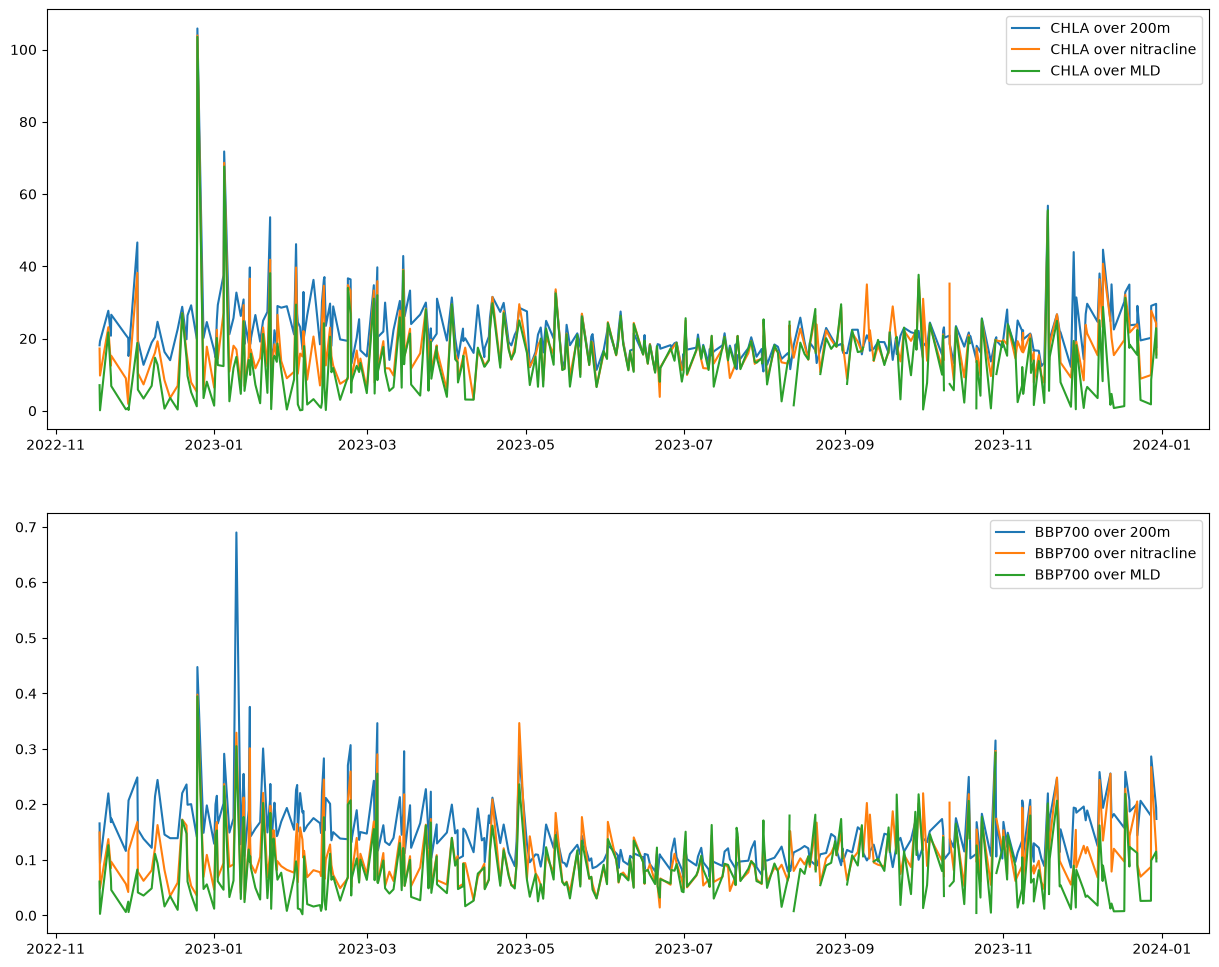

In [83]:
fig, axarr = plt.subplots(nrows = 2, figsize = [15,12])
axarr = axarr.flatten()

ax = axarr[0]

x = chla_integrated_200['JULD']
y = chla_integrated_200["CHLA_integrated"]
ax.plot(x, y, label = "CHLA over 200m")

x = chla_integrated_nitracline['JULD']
y = chla_integrated_nitracline["CHLA_integrated"]
ax.plot(x, y, label = "CHLA over nitracline")

x = chla_integrated_MLD['JULD']
y = chla_integrated_MLD["CHLA_integrated"]
ax.plot(x, y, label = "CHLA over MLD")

ax.legend()

ax = axarr[1]

x = bbp_integrated_200['JULD']
y = bbp_integrated_200["BBP700_integrated"]
ax.plot(x, y, label = "BBP700 over 200m")

x = bbp_integrated_nitracline['JULD']
y = bbp_integrated_nitracline["BBP700_integrated"]
ax.plot(x, y, label = "BBP700 over nitracline")

x = bbp_integrated_MLD['JULD']
y = bbp_integrated_MLD["BBP700_integrated"]
ax.plot(x, y, label = "BBP700 over MLD")

ax.legend()